In [1]:
from tracepro.app import TP_app
from tracepro.element import Element
from tracepro.source import Source

import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
mm = 1000

### Import data

In [3]:
data_path = r"C:\Users\prisc\Desktop\FAGOR\cabeza_lectora_param.txt"

with open(data_path, 'r', encoding='utf-8') as file:
    encoder = json.load(file)

In [4]:
print(encoder)

{'LED': {'length': 1000.0, 'width': 500.0, 'depth': 1000.0, 'global_x': 0.0, 'global_y': 1000.0, 'global_z': 0.0, 'wavelength': 0.88, 'band_width': 0.04, 'angle_incidence': -26.56505117707799, 'info': 'Parameters of the light source (LED).'}, 'detector_sensitive_area': {'length': 3340.0, 'width': 200.0, 'depth': 5000.0, 'global_x': 0.0, 'global_y': 1000.0, 'global_z': 5670.0, 'info': 'Parameters of the sensitive area of the detector.'}, 'detector_coating': {'length': 3540.0, 'width': 400.0, 'depth': 5200.0, 'global_x': 0.0, 'global_y': 1000.0, 'global_z': 5670.0, 'refractive_index': 1.52, 'info': 'Parameters of the detectors coat.'}, 'LED_grating': {'length': 4000.0, 'width': 500.0, 'depth': 6000.0, 'global_x': 0.0, 'global_y': 0.0, 'global_z': 0.0, 'period': 500.0, 'refractive_index': 1.52, 'info': 'Parameters of the first grating (amplitud), next to the LED source.'}, 'bottom_grating': {'length': 4000.0, 'width': 500.0, 'depth': 22000.0, 'global_x': 0.0, 'global_y': -3000.0, 'global_

### New file

In [5]:
working_path =r"C:\Software\tracepro\resultados\minimet cabeza lectora"
tp_file_name = "cabeza_lectora_minimet"

tp = TP_app(macro_path=working_path)
tp.new_file(file_name=tp_file_name, tp_path=working_path)

### Source

In [6]:
# General parameters:
degrees= True
rotation = (0, 0, 0)
orientation_method = ("angles", rotation)

working_distance_y_global = encoder["general"].get("working_distance_z") / mm
source_distance_y = 2 #inventado

# LED parameters:

wavelength = encoder["LED"].get("wavelength")
incidence_angle = encoder["LED"].get("angle_incidence")

LED_rotation = (incidence_angle, 0, 0)
LED_orientation = ("angles", LED_rotation)

l_z = encoder["LED"].get("length") / mm
l_y = encoder["LED"].get("width") / mm
l_x = encoder["LED"].get("depth") / mm

l_dimensions = (l_x, l_y, l_z)

l_center_x = encoder["LED"].get("global_x") / mm 
l_center_y =  encoder["LED"].get("global_y") / mm
l_center_z = encoder["LED"].get("global_z") / mm 

l_center = (l_center_x, l_center_y, l_center_z)

# Definition

led = Element(name="LED")
led_block = led.block(dimensions=l_dimensions, center=l_center, orientation_method=LED_orientation, degrees=degrees)
tp.add_function(led_block)

# Surface source
led_surf = Source(name="LED", source_num=0)
l_surf = led_surf.add_surface_source(object_name=led.name, surface_num=2, emission_type="lambertian", emission=2, units="radiometric", ang_dist=30, flux=10000)
# l_surf = led_surf.add_surface_source(object_name=led.name, surface_num=2, emission_type="irradiance", emission=1, units="radiometric", ang_dist=2, flux=10000)
tp.add_function(l_surf)

wave = led_surf.set_wavelength(wavelength=(wavelength, 1))
tp.add_function(wave)
# tp.execute()

### LED_grating

In [7]:
# LED grating parameters:

ldg_z = encoder["LED_grating"].get("length") / mm
ldg_y = encoder["LED_grating"].get("width") / mm
ldg_x = encoder["LED_grating"].get("depth") / mm

ldg_dimensions = (ldg_x, ldg_y, ldg_z)

ldg_center_x = encoder["LED_grating"].get("global_x") / mm
ldg_center_y = encoder["LED_grating"].get("global_y") / mm
ldg_center_z = encoder["LED_grating"].get("global_z") / mm

ldg_center = (ldg_center_x, ldg_center_y, ldg_center_z)

# Definition

LED_grating = Element(name="Led_grating")
ldg = LED_grating.block(dimensions=ldg_dimensions, center=ldg_center, orientation_method=orientation_method, degrees=degrees)
tp.add_function(ldg)
# tp.execute()

### Top_grating

In [8]:
# Top grating parameters:

tg_z = encoder["top_grating"].get("length") / mm
tg_y = encoder["top_grating"].get("width") / mm
tg_x = encoder["top_grating"].get("depth") / mm

tg_dimensions = (tg_x, tg_y, tg_z)

tg_center_x = encoder["top_grating"].get("global_x") / mm
tg_center_y = encoder["top_grating"].get("global_y") / mm
tg_center_z = encoder["top_grating"].get("global_z") / mm

tg_center = (tg_center_x, tg_center_y, tg_center_z)

# Definition

top_grating = Element(name="Top_grating")
tg = top_grating.block(dimensions=tg_dimensions, center=tg_center, orientation_method=orientation_method, degrees=degrees)
tp.add_function(tg)
# tp.execute()

### Bottom grating

In [9]:
# Bottom grating parameters:

bg_z = encoder["bottom_grating"].get("length") / mm
bg_y = encoder["bottom_grating"].get("width") / mm
bg_x = encoder["bottom_grating"].get("depth") / mm

bg_dimensions = (bg_x, bg_y, bg_z)

bg_center_x = encoder["bottom_grating"].get("global_x") / mm
bg_center_y = encoder["bottom_grating"].get("global_y") / mm
bg_center_z = encoder["bottom_grating"].get("global_z") / mm

bg_center = (bg_center_x, bg_center_y, bg_center_z)

# Definition

bottom_grating = Element(name="Bottom_grating")
bg = bottom_grating.block(dimensions=bg_dimensions, center=bg_center, orientation_method=orientation_method, degrees=degrees)
tp.add_function(bg)
# tp.execute()

### Glass

In [10]:
# Glass parameters:

g_z = encoder["glass"].get("length") / mm
g_y = encoder["glass"].get("width") / mm
g_x = encoder["glass"].get("depth") / mm

g_dimensions = (g_x, g_y, g_z)

g_center_x = encoder["glass"].get("global_x") / mm
g_center_y = encoder["glass"].get("global_y") / mm
g_center_z = encoder["glass"].get("global_z") / mm

g_center = (g_center_x, g_center_y, g_center_z)

# Definition

glass = Element(name="Glass")
g = glass.block(dimensions=g_dimensions, center=g_center, orientation_method=orientation_method, degrees=degrees)
tp.add_function(g)
# tp.execute()

### Detector sensitive area

In [11]:
# Detector sensitive area parameters:

dsa_z = encoder["detector_sensitive_area"].get("length") / mm
dsa_y = encoder["detector_sensitive_area"].get("width") / mm
dsa_x = encoder["detector_sensitive_area"].get("depth") / mm

dsa_dimensions = (dsa_x, dsa_y, dsa_z)

dsa_center_x = encoder["detector_sensitive_area"].get("global_x") / mm
dsa_center_y = encoder["detector_sensitive_area"].get("global_y") / mm
dsa_center_z = encoder["detector_sensitive_area"].get("global_z") / mm

dsa_center = (dsa_center_x, dsa_center_y, dsa_center_z)

# Definition

detector = Element(name="Detector")
dsa = detector.block(dimensions=dsa_dimensions, center=dsa_center, orientation_method=orientation_method, degrees=degrees)
tp.add_function(dsa)
# tp.execute()

### Detector coating

In [12]:
# Detector sensitive area parameters:

dc_z = encoder["detector_coating"].get("length") / mm
dc_y = encoder["detector_coating"].get("width") / mm
dc_x = encoder["detector_coating"].get("depth") / mm

dc_dimensions = (dc_x, dc_y, dc_z)

dc_center_x = encoder["detector_coating"].get("global_x") / mm
dc_center_y = encoder["detector_coating"].get("global_y") / mm
dc_center_z = encoder["detector_coating"].get("global_z") / mm

dc_center = (dc_center_x, dc_center_y, dc_center_z)

# Definition

detector_coat = Element(name="Detector_coat")
dc = detector_coat.block(dimensions=dc_dimensions, center=dc_center, orientation_method=orientation_method, degrees=degrees)
tp.add_function(dc)
# tp.execute()

### Name surfaces and properties

In [13]:
refractive_index = ("SCHOTT", "BK7")
tp.apply_material(material=refractive_index, object_name=LED_grating.name)
tp.apply_material(material=refractive_index, object_name=glass.name)

tp.apply_property(property=("default", "perfect absorber"), object_name=top_grating.name, surface_num=0)
tp.name_surfaces(name="Tapa", object_name=top_grating.name, surface_num=0)

tp.apply_property(property=("default", "mirror"), object_name=top_grating.name, surface_num=2)

tp.apply_property(property=("default", "mirror"), object_name=bottom_grating.name, surface_num=4)

tp.apply_property(property=("default", "perfect absorber"), object_name=detector.name, surface_num=2)
tp.name_surfaces(name="Plano de deteccion", object_name=detector.name, surface_num=2)

### Color

In [14]:
tp.apply_color(object_name=led.name, color=(255, 255, 0)) 
tp.apply_color(object_name=LED_grating.name, color=(128, 128, 192), transparency=True)
tp.apply_color(object_name=glass.name, color=(0, 128, 255), transparency=True)
tp.apply_color(object_name=bottom_grating.name, color=(128, 128, 128))
tp.apply_color(object_name=top_grating.name, color=(128, 128, 128))
tp.apply_color(object_name=top_grating.name, surface_num=0, color=(0, 0, 0))
tp.apply_color(object_name=detector.name, color=(0, 0, 0))
tp.apply_color(object_name=detector_coat.name, color=(255, 255, 255), transparency=True)

### Raytracing_1

In [15]:
raytracing = Source.raytrace()
tp.add_function(raytracing)

tp.select_detection_surface(object_name=detector.name, surface_num=2)

irradiance_analysis = led_surf.irradiance_analysis(ray_type="absorbed", smooth=True)
tp.add_function(irradiance_analysis)

### Bottom_gratting_y

In [16]:
y_distances = np.linspace(-2, -7, 5)

for i, y_dist in enumerate(y_distances):
    tp.move_object(object_name=bottom_grating.name, mode="absolute", distance=(0, y_dist, bg_center_z))

    raytrace = Source.raytrace()
    tp.add_function(raytrace)

    tp.select_detection_surface(object_name=detector.name, surface_num=2)
    irradiance = led_surf.irradiance_analysis(ray_type="absorbed", smooth=True)
    tp.add_function(irradiance)
    tp.save_irradiance_map(save_path=working_path, file_name=f"desp_y_{i+1}", extension="txt")


tp.move_object(object_name=bottom_grating.name, mode="absolute", distance=(0, bg_center_y, bg_center_z))
# tp.save_file(file_name=tp_file_name, tp_path=working_path)

### bottom_grating_X

In [17]:
rotation_point = (0, 0, 0)
object_ref = True
incrementos = 1
num_positions = 5
x_angles = np.ones(num_positions) * incrementos

for i, x_ang in enumerate(x_angles):
    tp.rotate_object(object_name=bottom_grating.name, angle=x_ang, axis_type=0, degrees=True, rotation_point=rotation_point, object_ref=object_ref)

    raytrace = Source.raytrace()
    tp.add_function(raytrace)

    tp.select_detection_surface(object_name=detector.name, surface_num=2)
    irradiance = led_surf.irradiance_analysis(ray_type="absorbed", smooth=True)
    tp.add_function(irradiance)
    tp.save_irradiance_map(save_path=working_path, file_name=f"desp_X_{i+1}", extension="txt")
    
pos_original = -(np.sum(x_angles))
tp.rotate_object(object_name=bottom_grating.name, angle=pos_original, axis_type=0, degrees=True, rotation_point=rotation_point, object_ref=object_ref)
    
# tp.save_file(file_name=tp_file_name, tp_path=working_path)

### bottom_grating_Y

In [18]:
incrementos = 1
num_positions = 5
y_angles = np.ones(num_positions) * incrementos

for i, y_ang in enumerate(x_angles):
    tp.rotate_object(object_name=bottom_grating.name, angle=y_ang, axis_type=1, degrees=True, rotation_point=rotation_point, object_ref=object_ref)

    raytrace = Source.raytrace()
    tp.add_function(raytrace)

    tp.select_detection_surface(object_name=detector.name, surface_num=2)
    irradiance = led_surf.irradiance_analysis(ray_type="absorbed", smooth=True)
    tp.add_function(irradiance)
    tp.save_irradiance_map(save_path=working_path, file_name=f"desp_Y_{i+1}", extension="txt")
    
pos_original = -(np.sum(y_angles))
tp.rotate_object(object_name=bottom_grating.name, angle=pos_original, axis_type=1, degrees=True, rotation_point=rotation_point, object_ref=object_ref)
    
# tp.save_file(file_name=tp_file_name, tp_path=working_path)

### bottom_grating_z

In [19]:
incrementos = 1
num_positions = 5
z_angles = np.ones(num_positions) * incrementos

for i, z_ang in enumerate(z_angles):
    tp.rotate_object(object_name=bottom_grating.name, angle=z_ang, axis_type=2, degrees=True, rotation_point=rotation_point, object_ref=object_ref)

    raytrace = Source.raytrace()
    tp.add_function(raytrace)

    tp.select_detection_surface(object_name=detector.name, surface_num=2)
    irradiance = led_surf.irradiance_analysis(ray_type="absorbed", smooth=True)
    tp.add_function(irradiance)
    tp.save_irradiance_map(save_path=working_path, file_name=f"desp_Z_{i+1}", extension="txt")

pos_original = - (np.sum(z_angles))
tp.rotate_object(object_name=bottom_grating.name, angle=pos_original, axis_type=2, degrees=True, rotation_point=rotation_point, object_ref=object_ref)
    
# tp.save_file(file_name=tp_file_name, tp_path=working_path)

In [20]:
tp.execute(graphic_window=True)

Successfully completed


'()'

In [21]:
# tp.delete_macro()

### Representación

In [22]:
num_distances = len(y_distances)
file_names = []

for i, file in enumerate(y_distances):
    name = f"desp_y_{i + 1}"
    file_names.append(name)

irradiance_map_data_y = tp.txt_map2array(txt_path=working_path, num_files=len(y_distances), file_name=file_names)

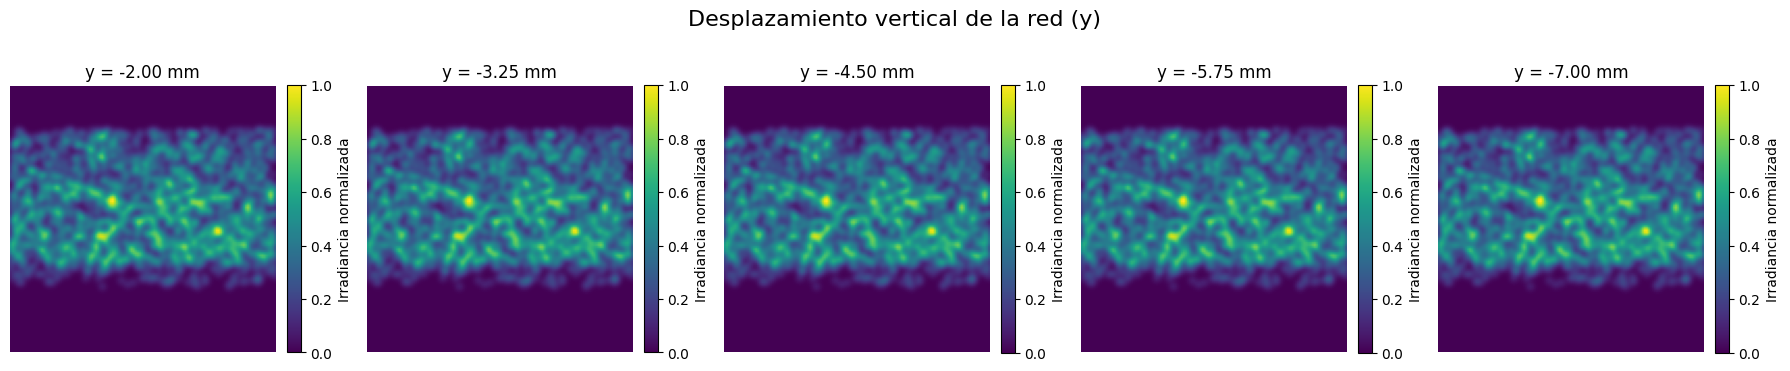

In [23]:
global_min = irradiance_map_data_y.min()
global_max = irradiance_map_data_y.max()

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i in range(5):
    # ax = axes[i // 5, i % 5]
    ax = axes[i]

    data = irradiance_map_data_y[:, :, i]
    data_norm = (data - global_min) / (global_max - global_min)

    im = ax.imshow(data_norm, origin="lower", vmin=0, vmax=1)
    ax.set_title(f"y = {y_distances[i]:.2f} mm")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Irradiancia normalizada")

plt.suptitle("Desplazamiento vertical de la red (y)", fontsize=16)
plt.tight_layout()
plt.show()

In [24]:
num_distances = len(x_angles)
file_names = []

for i, file in enumerate(x_angles):
    name = f"desp_X_{i + 1}"
    file_names.append(name)

irradiance_map_data_X = tp.txt_map2array(txt_path=working_path, num_files=num_distances, file_name=file_names)

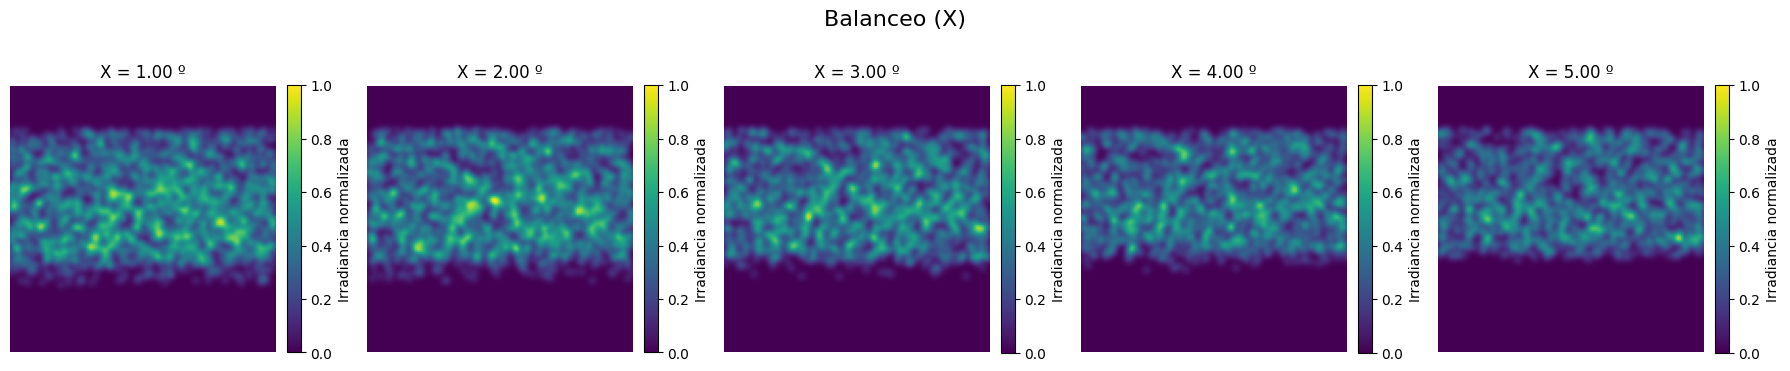

In [25]:
global_min = irradiance_map_data_X.min()
global_max = irradiance_map_data_X.max()

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
angle = 0

for i in range(5):
    # ax = axes[i // 5, i % 5]
    ax = axes[i]

    data = irradiance_map_data_X[:, :, i]
    data_norm = (data - global_min) / (global_max - global_min)

    angle += x_angles[i]

    im = ax.imshow(data_norm, origin="lower", vmin=0, vmax=1)
    ax.set_title(f"X = {angle:.2f} º")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Irradiancia normalizada")

plt.suptitle("Balanceo (X)", fontsize=16)
plt.tight_layout()
plt.show()

In [26]:
num_distances = len(y_angles)
file_names = []

for i, file in enumerate(y_angles):
    name = f"desp_Y_{i + 1}"
    file_names.append(name)

irradiance_map_data_Y = tp.txt_map2array(txt_path=working_path, num_files=num_distances, file_name=file_names)

In [27]:
print(irradiance_map_data_Y.shape)

(128, 128, 5)


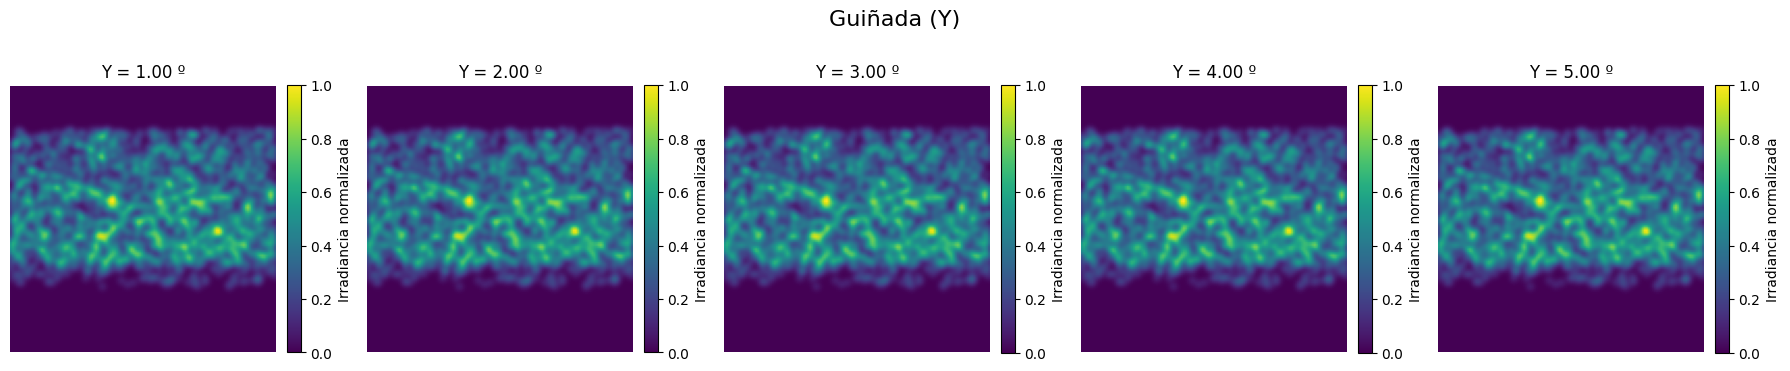

In [28]:
global_min = irradiance_map_data_Y.min()
global_max = irradiance_map_data_Y.max()

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

angle = 0

for i in range(5):
    # ax = axes[i // 5, i % 5]
    ax = axes[i]

    data = irradiance_map_data_Y[:, :, i]
    data_norm = (data - global_min) / (global_max - global_min)

    angle += y_angles[i]

    im = ax.imshow(data_norm, origin="lower", vmin=0, vmax=1)
    ax.set_title(f"Y = {angle:.2f} º")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Irradiancia normalizada")

plt.suptitle("Guiñada (Y)", fontsize=16)
plt.tight_layout()
plt.show()

In [29]:
num_distances = len(z_angles)
file_names = []

for i, file in enumerate(z_angles):
    name = f"desp_Z_{i + 1}"
    file_names.append(name)

irradiance_map_data_Z = tp.txt_map2array(txt_path=working_path, num_files=num_distances, file_name=file_names)

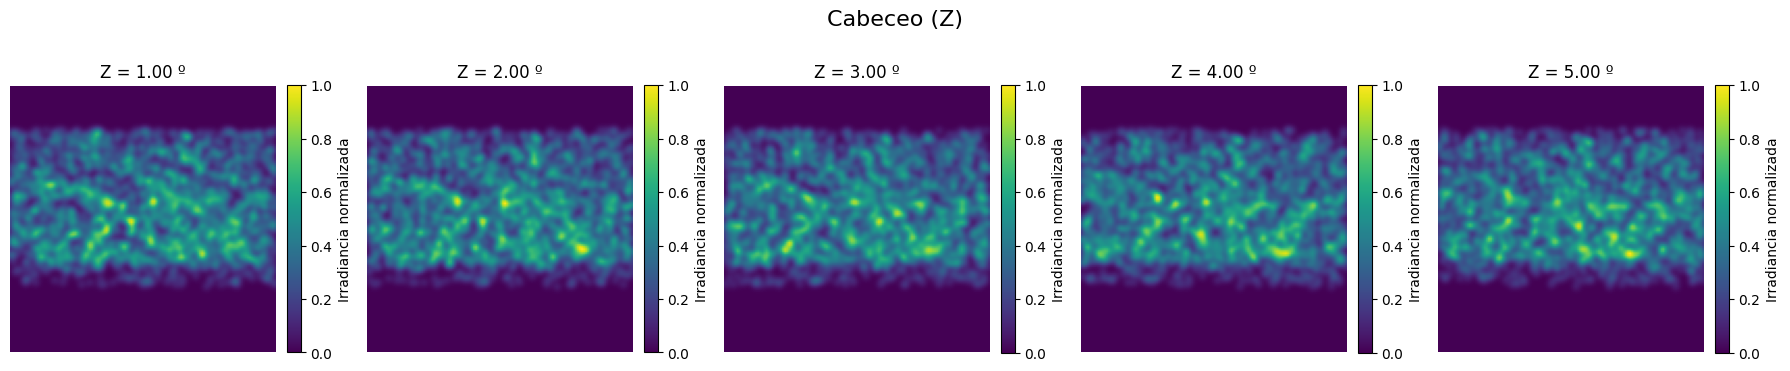

In [30]:
global_min = irradiance_map_data_Z.min()
global_max = irradiance_map_data_Z.max()

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

angle = 0

for i in range(5):
    # ax = axes[i // 5, i % 5]
    ax = axes[i]

    data = irradiance_map_data_Z[:, :, i]
    data_norm = (data - global_min) / (global_max - global_min)

    angle += z_angles[i]

    im = ax.imshow(data_norm, origin="lower", vmin=0, vmax=1)
    ax.set_title(f"Z = {angle:.2f} º")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Irradiancia normalizada")

plt.suptitle("Cabeceo (Z)", fontsize=16)
plt.tight_layout()
plt.show()